# 01 - Data Download & Exploratory Data Analysis
**IS5126 Cross-Regional PD Model Transferability Study**

This notebook covers:
1. Download Lending Club dataset from Kaggle
2. Data overview & quality assessment
3. Target variable (default) definition
4. Feature exploration & distributions
5. Missing value analysis
6. Correlation & multicollinearity check
7. Export cleaned dataset for next steps

## 0. Setup

In [1]:
!pip install -q kagglehub shap category_encoders lightgbm xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'primary': '#1F4E79',
    'accent': '#2E86AB',
    'good': '#28A745',
    'bad': '#DC3545',
    'neutral': '#6C757D',
    'light': '#D6E4F0'
}

# Create all output directories upfront
os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print('Setup complete!')

Setup complete!


## 1. Mount Google Drive & Download Data

Data is saved to Google Drive so you don't need to re-download every time Colab disconnects.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Project folder on Google Drive
DRIVE_DIR = '/content/drive/MyDrive/is5126'
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/data/processed', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/figures', exist_ok=True)

Mounted at /content/drive


In [4]:
# Check if data already exists on Drive (skip download if so)
DRIVE_DATA_PATH = f'{DRIVE_DIR}/accepted_2007_to_2018Q4.csv.gz'

if os.path.exists(DRIVE_DATA_PATH):
    csv_path = DRIVE_DATA_PATH
    print(f'Data already on Drive: {csv_path}')
    print(f'Size: {os.path.getsize(csv_path)/1024/1024:.1f} MB')
else:
    print('Data not found on Drive. Downloading from Kaggle...')
    import kagglehub
    path = kagglehub.dataset_download('wordsforthewise/lending-club')

    print(f'\nDownloaded to: {path}')
    for f in os.listdir(path):
        size = os.path.getsize(os.path.join(path, f)) / 1024 / 1024
        print(f'  {f} ({size:.1f} MB)')

    # Copy to Drive for persistence
    import shutil
    src = os.path.join(path, 'accepted_2007_to_2018Q4.csv.gz')
    shutil.copy(src, DRIVE_DATA_PATH)
    csv_path = DRIVE_DATA_PATH
    print(f'\nCopied to Drive: {csv_path}')

Data not found on Drive. Downloading from Kaggle...
Using Colab cache for faster access to the 'lending-club' dataset.

Downloaded to: /kaggle/input/lending-club
  rejected_2007_to_2018Q4.csv.gz (243.6 MB)
  accepted_2007_to_2018Q4.csv.gz (374.4 MB)
  accepted_2007_to_2018q4.csv (0.0 MB)
  rejected_2007_to_2018q4.csv (0.0 MB)

Copied to Drive: /content/drive/MyDrive/is5126/accepted_2007_to_2018Q4.csv.gz


In [5]:
print('Loading data... (this may take a minute)')
df_raw = pd.read_csv(csv_path, low_memory=False)
print(f'Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

Loading data... (this may take a minute)
Loaded: 2,260,701 rows x 151 columns


## 2. Data Overview

In [6]:
df_raw.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.000,3600.000,3600.000,36 months,13.990,123.030,C,C4,leadman,10+ years,MORTGAGE,55000.000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.910,0.000,Aug-2003,675.000,679.000,1.000,30.000,NaN,7.000,0.000,2765.000,29.700,13.000,w,0.000,0.000,...,178050.000,7746.000,2400.000,13734.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.000,24700.000,24700.000,36 months,11.990,820.280,C,C1,Engineer,10+ years,MORTGAGE,65000.000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.060,1.000,Dec-1999,715.000,719.000,4.000,6.000,NaN,22.000,0.000,21470.000,19.200,38.000,w,0.000,0.000,...,314017.000,39475.000,79300.000,24667.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.000,20000.000,20000.000,60 months,10.780,432.660,B,B4,truck driver,10+ years,MORTGAGE,63000.000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.780,0.000,Aug-2000,695.000,699.000,0.000,NaN,NaN,6.000,0.000,7869.000,56.200,18.000,w,0.000,0.000,...,218418.000,18696.000,6200.000,14877.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
dtype_summary = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'non_null': df_raw.notnull().sum(),
    'null_count': df_raw.isnull().sum(),
    'null_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'nunique': df_raw.nunique(),
    'sample_value': df_raw.iloc[0]
})
dtype_summary.sort_values('null_pct', ascending=False).head(30)

,dtype,non_null,null_count,null_pct,nunique,sample_value
member_id,float64,0,2260701,100.000,0,NaN
orig_projected_additional_accrued_interest,float64,8651,2252050,99.620,7487,NaN
hardship_reason,object,10917,2249784,99.520,9,NaN
hardship_payoff_balance_amount,float64,10917,2249784,99.520,10893,NaN
hardship_last_payment_amount,float64,10917,2249784,99.520,9045,NaN
payment_plan_start_date,object,10917,2249784,99.520,27,NaN
hardship_type,object,10917,2249784,99.520,1,NaN
hardship_status,object,10917,2249784,99.520,3,NaN
hardship_start_date,object,10917,2249784,99.520,27,NaN
deferral_term,float64,10917,2249784,99.520,1,NaN


In [8]:
df_raw.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
member_id,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.000,15046.931,9190.245,500.000,8000.000,12900.000,20000.000,40000.000
funded_amnt,2260668.000,15041.664,9188.413,500.000,8000.000,12875.000,20000.000,40000.000
funded_amnt_inv,2260668.000,15023.438,9192.332,0.000,8000.000,12800.000,20000.000,40000.000
int_rate,2260668.000,13.093,4.832,5.310,9.490,12.620,15.990,30.990
installment,2260668.000,445.807,267.174,4.930,251.650,377.990,593.320,1719.830
annual_inc,2260664.000,77992.429,112696.200,0.000,46000.000,65000.000,93000.000,110000000.000
dti,2258957.000,18.824,14.183,-1.000,11.890,17.840,24.490,999.000
delinq_2yrs,2260639.000,0.307,0.867,0.000,0.000,0.000,0.000,58.000
fico_range_low,2260668.000,698.588,33.010,610.000,675.000,690.000,715.000,845.000


## 3. Target Variable Definition

**Critical step.** We map `loan_status` to a binary target:
- **Default (1):** Charged Off, Default, Late (31-120 days)
- **Non-default (0):** Fully Paid
- **Excluded:** Current, In Grace Period, Late (16-30 days) — outcome not yet determined

In [9]:
print('=== loan_status Distribution ===')
status_counts = df_raw['loan_status'].value_counts()
status_pct = df_raw['loan_status'].value_counts(normalize=True) * 100
status_df = pd.DataFrame({'Count': status_counts, 'Pct': status_pct.round(2)})
print(status_df)
print(f'\nTotal: {len(df_raw):,}')

=== loan_status Distribution ===
                                                      Count    Pct
loan_status                                                       
Fully Paid                                          1076751 47.630
Current                                              878317 38.850
Charged Off                                          268559 11.880
Late (31-120 days)                                    21467  0.950
In Grace Period                                        8436  0.370
Late (16-30 days)                                      4349  0.190
Does not meet the credit policy. Status:Fully Paid     1988  0.090
Does not meet the credit policy. Status:Charged...      761  0.030
Default                                                  40  0.000

Total: 2,260,701


In [10]:
default_statuses = ['Charged Off', 'Default', 'Late (31-120 days)']
non_default_statuses = ['Fully Paid']

df = df_raw[df_raw['loan_status'].isin(default_statuses + non_default_statuses)].copy()
df['default'] = df['loan_status'].isin(default_statuses).astype(int)

print(f'After filtering: {len(df):,} loans ({len(df)/len(df_raw)*100:.1f}% of original)')
print(f'\nTarget distribution:')
print(df['default'].value_counts())
print(f'\nDefault rate: {df["default"].mean()*100:.2f}%')

After filtering: 1,366,817 loans (60.5% of original)

Target distribution:
default
0    1076751
1     290066
Name: count, dtype: int64

Default rate: 21.22%


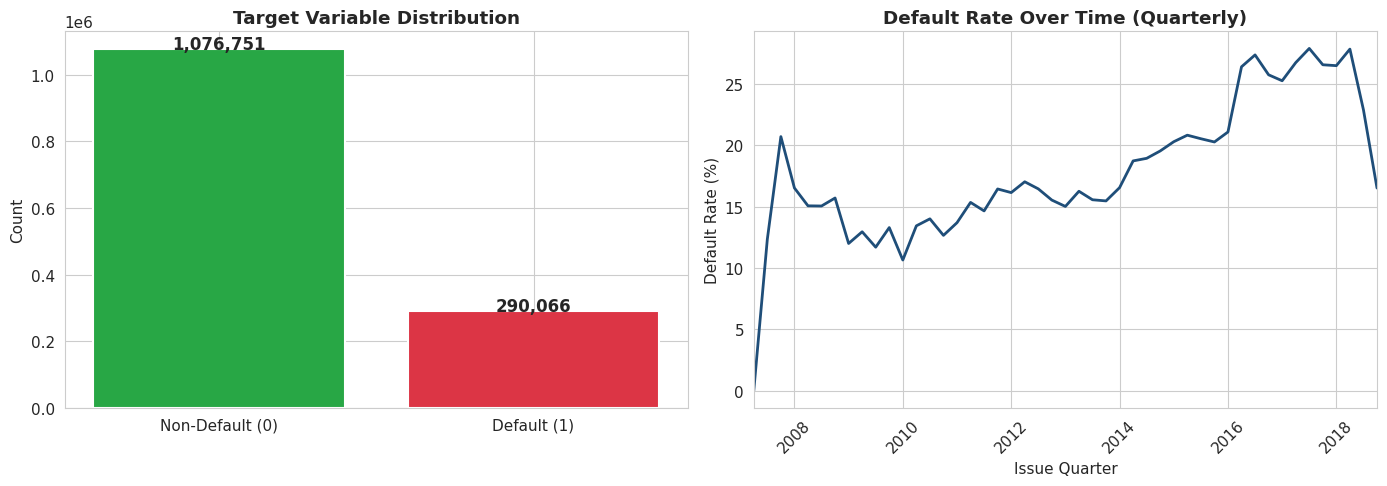


Note: ~20% default rate is typical for Lending Club. Class imbalance is moderate.
We will handle this with stratified sampling and threshold-based metrics.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['default'].value_counts()
bars = axes[0].bar(['Non-Default (0)', 'Default (1)'], counts.values,
                    color=[COLORS['good'], COLORS['bad']], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Target Variable Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Default rate over time
if 'issue_d' in df.columns:
    df['issue_date'] = pd.to_datetime(df['issue_d'], format='mixed', errors='coerce')
    quarterly = df.groupby(df['issue_date'].dt.to_period('Q'))['default'].mean() * 100
    quarterly.plot(ax=axes[1], color=COLORS['primary'], linewidth=2)
    axes[1].set_title('Default Rate Over Time (Quarterly)', fontweight='bold')
    axes[1].set_ylabel('Default Rate (%)')
    axes[1].set_xlabel('Issue Quarter')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote: ~20% default rate is typical for Lending Club. Class imbalance is moderate.')
print('We will handle this with stratified sampling and threshold-based metrics.')

## 4. Remove Data Leakage & Low-Value Features

**Critical:** Some features are only available *after* the loan is issued. Using them = data leakage.

In [12]:
# Post-origination / leakage features
leakage_cols = [
    'funded_amnt', 'funded_amnt_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d',
    'out_prncp', 'out_prncp_inv',
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'hardship_start_date', 'hardship_end_date',
    'hardship_amount', 'hardship_length',
    'hardship_dpd', 'hardship_loan_status',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'payment_plan_start_date',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date',
    'settlement_amount', 'settlement_percentage', 'settlement_term',
]

# Identifiers / non-predictive
id_cols = ['id', 'member_id', 'url', 'policy_code']

# Redundant
redundant_cols = ['loan_status', 'issue_d', 'issue_date', 'zip_code', 'title']

drop_cols = leakage_cols + id_cols + redundant_cols
existing_drop = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=existing_drop)

print(f'Dropped {len(existing_drop)} columns (leakage + IDs + redundant)')
print(f'Remaining: {df.shape[1]} columns')

Dropped 44 columns (leakage + IDs + redundant)
Remaining: 109 columns


In [13]:
# Drop columns with > 70% missing
missing_pct = df.isnull().mean()
high_missing = missing_pct[missing_pct > 0.70].index.tolist()

print(f'Columns with >70% missing ({len(high_missing)}):')
for col in high_missing:
    print(f'  {col}: {missing_pct[col]*100:.1f}% missing')

df = df.drop(columns=high_missing)
print(f'\nAfter dropping: {df.shape[1]} columns remain')

Columns with >70% missing (22):
  desc: 91.0% missing
  mths_since_last_record: 83.0% missing
  mths_since_last_major_derog: 73.6% missing
  annual_inc_joint: 98.0% missing
  dti_joint: 98.0% missing
  verification_status_joint: 98.0% missing
  mths_since_recent_bc_dlq: 76.3% missing
  revol_bal_joint: 98.5% missing
  sec_app_fico_range_low: 98.5% missing
  sec_app_fico_range_high: 98.5% missing
  sec_app_earliest_cr_line: 98.5% missing
  sec_app_inq_last_6mths: 98.5% missing
  sec_app_mort_acc: 98.5% missing
  sec_app_open_acc: 98.5% missing
  sec_app_revol_util: 98.5% missing
  sec_app_open_act_il: 98.5% missing
  sec_app_num_rev_accts: 98.5% missing
  sec_app_chargeoff_within_12_mths: 98.5% missing
  sec_app_collections_12_mths_ex_med: 98.5% missing
  sec_app_mths_since_last_major_derog: 99.5% missing
  deferral_term: 99.5% missing
  orig_projected_additional_accrued_interest: 99.6% missing

After dropping: 87 columns remain


## 5. Clean Key Features

In [14]:
# int_rate: "13.56%" -> 13.56
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.rstrip('%').astype(float)
    print('Cleaned int_rate')

# revol_util: "65.3%" -> 65.3
if 'revol_util' in df.columns and df['revol_util'].dtype == 'object':
    df['revol_util'] = df['revol_util'].str.rstrip('%').astype(float)
    print('Cleaned revol_util')

# term: " 36 months" -> 36
if df['term'].dtype == 'object':
    df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)
    print('Cleaned term')

# emp_length -> numeric
if 'emp_length' in df.columns and df['emp_length'].dtype == 'object':
    emp_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8, '9 years': 9, '10+ years': 10
    }
    df['emp_length_num'] = df['emp_length'].map(emp_map)
    print(f'Created emp_length_num (NaN: {df["emp_length_num"].isnull().mean()*100:.1f}%)')

# earliest_cr_line -> credit history length in months
if 'earliest_cr_line' in df.columns:
    ecl = pd.to_datetime(df['earliest_cr_line'], format='mixed', errors='coerce')
    ref_date = pd.Timestamp('2018-12-01')
    df['credit_history_months'] = ((ref_date - ecl).dt.days / 30.44).round(0)
    print('Created credit_history_months')

# FICO: average of range
if 'fico_range_low' in df.columns and 'fico_range_high' in df.columns:
    df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
    print('Created fico_score')

print(f'\nShape after cleaning: {df.shape}')

Cleaned term
Created emp_length_num (NaN: 5.9%)
Created credit_history_months
Created fico_score

Shape after cleaning: (1366817, 90)


## 6. Feature Categorization

In [15]:
feature_categories = {
    'Loan Characteristics': [
        'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'purpose',
    ],
    'Borrower Profile': [
        'emp_title', 'emp_length', 'emp_length_num', 'home_ownership',
        'annual_inc', 'verification_status', 'addr_state',
    ],
    'Credit History': [
        'dti', 'delinq_2yrs', 'fico_score', 'fico_range_low', 'fico_range_high',
        'credit_history_months', 'inq_last_6mths', 'open_acc', 'pub_rec',
        'revol_bal', 'revol_util', 'total_acc',
        'initial_list_status', 'application_type',
    ],
    'Extended Credit Metrics': [
        'mort_acc', 'pub_rec_bankruptcies',
        'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
        'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
        'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats',
        'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
        'pct_tl_nvr_dlq', 'percent_bc_gt_75',
        'tot_coll_amt', 'tot_cur_bal', 'tot_hi_cred_lim',
        'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit',
        'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
        'chargeoff_within_12_mths', 'collections_12_mths_ex_med',
        'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
        'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
        'mths_since_recent_bc', 'mths_since_recent_inq',
        'tax_liens', 'total_bal_il', 'total_cu_tl', 'total_rev_hi_lim',
    ],
    'Text Features (for LLM)': [
        'emp_title', 'desc',
    ]
}

for category, features in feature_categories.items():
    existing = [f for f in features if f in df.columns]
    print(f'\n{"="*60}')
    print(f'{category} ({len(existing)} features)')
    print('='*60)
    for f in existing:
        dtype = df[f].dtype
        null_pct = df[f].isnull().mean() * 100
        if dtype in ['float64', 'int64', 'int32']:
            print(f'  {f:35s} | {str(dtype):8s} | {null_pct:5.1f}% null | mean={df[f].mean():.2f}')
        else:
            print(f'  {f:35s} | {str(dtype):8s} | {null_pct:5.1f}% null | {df[f].nunique()} unique')


Loan Characteristics (7 features)
  loan_amnt                           | float64  |   0.0% null | mean=14459.65
  term                                | int64    |   0.0% null | mean=41.86
  int_rate                            | float64  |   0.0% null | mean=13.28
  installment                         | float64  |   0.0% null | mean=439.05
  grade                               | object   |   0.0% null | 7 unique
  sub_grade                           | object   |   0.0% null | 35 unique
  purpose                             | object   |   0.0% null | 14 unique

Borrower Profile (7 features)
  emp_title                           | object   |   6.4% null | 381808 unique
  emp_length                          | object   |   5.9% null | 11 unique
  emp_length_num                      | float64  |   5.9% null | mean=5.96
  home_ownership                      | object   |   0.0% null | 6 unique
  annual_inc                          | float64  |   0.0% null | mean=76259.79
  verification_statu

## 7. Key Feature Distributions by Default Status

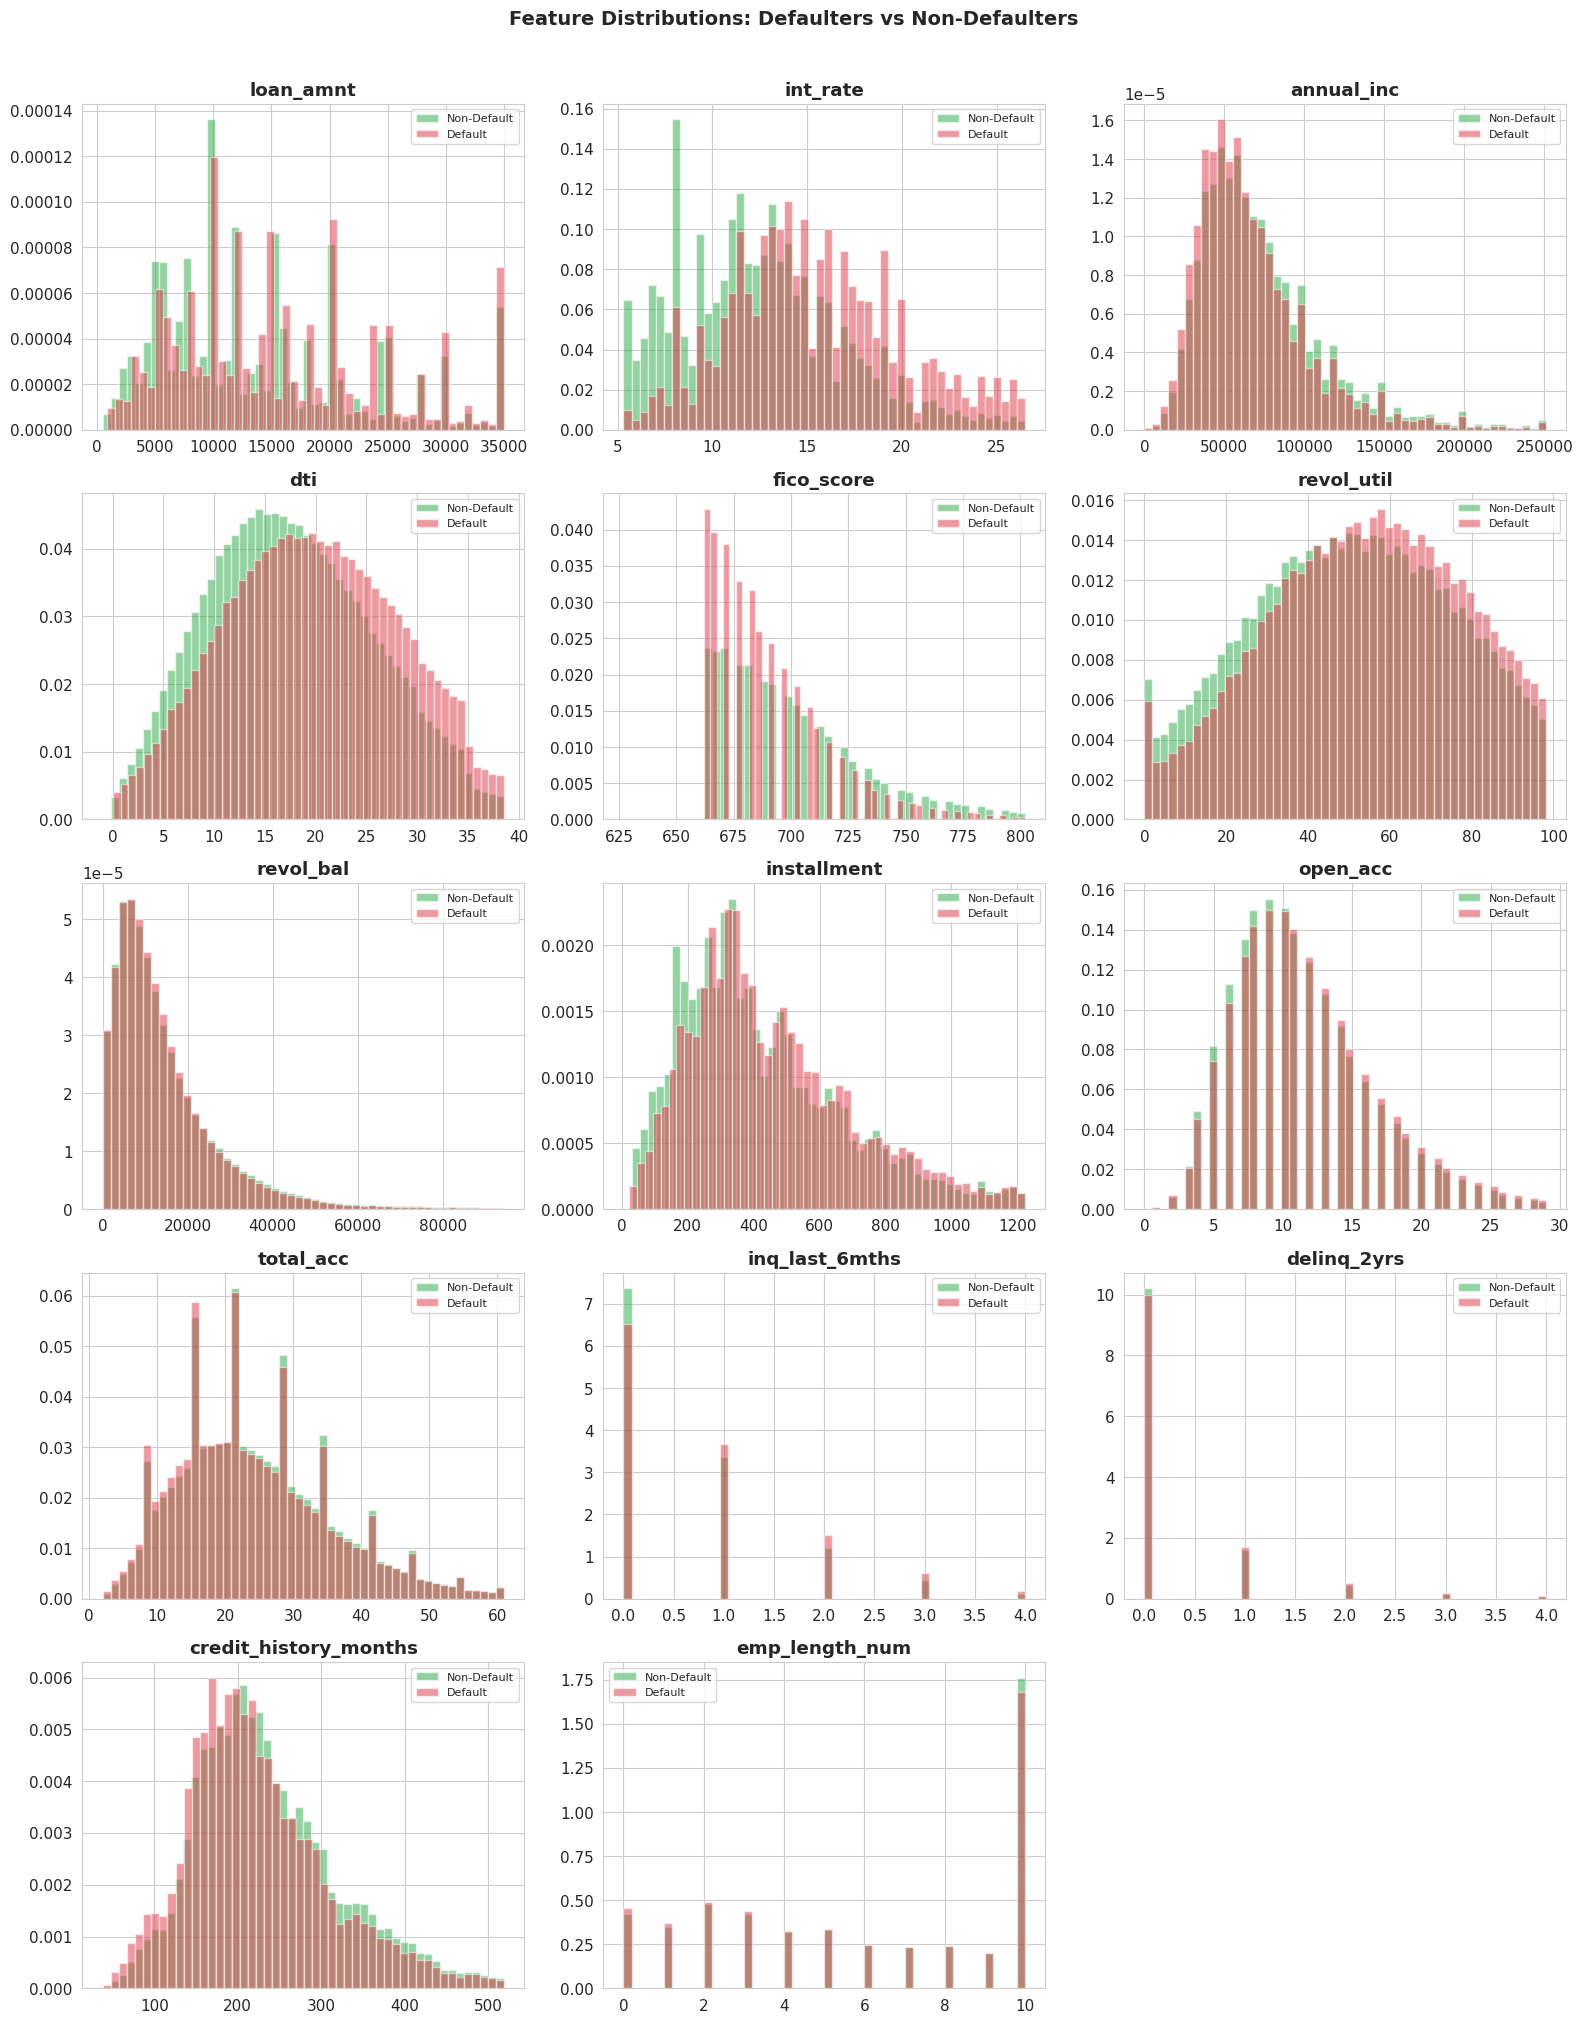

In [16]:
key_numeric = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
               'fico_score', 'revol_util', 'revol_bal',
               'installment', 'open_acc', 'total_acc',
               'inq_last_6mths', 'delinq_2yrs',
               'credit_history_months', 'emp_length_num']
key_numeric = [f for f in key_numeric if f in df.columns]

n_cols = 3
n_rows = (len(key_numeric) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    ax = axes[i]
    upper = df[col].quantile(0.99)
    plot_data = df[df[col] <= upper] if pd.notna(upper) else df

    for label, color, name in [(0, COLORS['good'], 'Non-Default'), (1, COLORS['bad'], 'Default')]:
        subset = plot_data[plot_data['default'] == label][col].dropna()
        ax.hist(subset, bins=50, alpha=0.5, color=color, density=True, label=name)

    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Defaulters vs Non-Defaulters', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Statistical comparison table
comparison = df.groupby('default')[key_numeric].mean().T
comparison.columns = ['Non-Default', 'Default']
comparison['Diff (%)'] = ((comparison['Default'] - comparison['Non-Default']) / comparison['Non-Default'] * 100).round(1)
comparison = comparison.round(3)

print('=== Mean Feature Values by Default Status ===')
print('(Positive Diff% = higher for defaulters)\n')
print(comparison.to_string())

=== Mean Feature Values by Default Status ===
(Positive Diff% = higher for defaulters)

                       Non-Default   Default  Diff (%)
loan_amnt                14134.370 15667.133    10.800
int_rate                    12.623    15.705    24.400
annual_inc               77705.946 70891.553    -8.800
dti                         17.812    20.169    13.200
fico_score                 700.264   690.183    -1.400
revol_util                  51.075    54.370     6.500
revol_bal                16471.246 15327.403    -6.900
installment                431.323   467.753     8.400
open_acc                    11.517    11.882     3.200
total_acc                   25.049    24.593    -1.800
inq_last_6mths               0.624     0.767    22.800
delinq_2yrs                  0.309     0.352    13.900
credit_history_months      238.949   227.388    -4.800
emp_length_num               5.992     5.846    -2.400


## 8. Categorical Feature Analysis

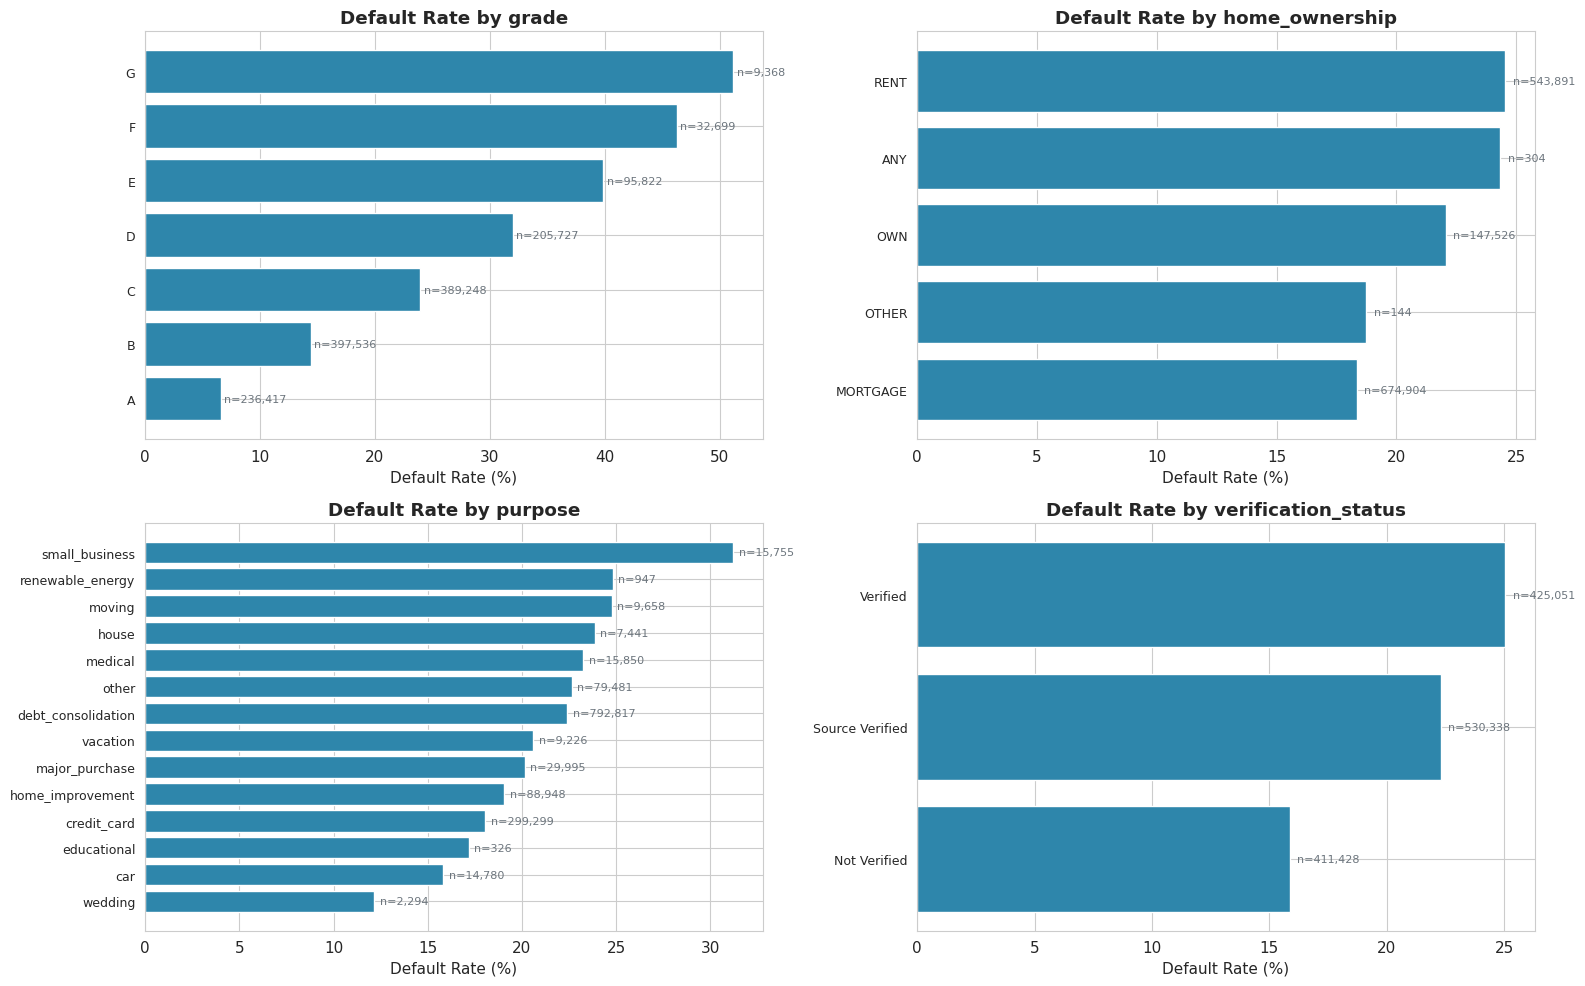

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

cat_features = ['grade', 'home_ownership', 'purpose', 'verification_status']
cat_features = [f for f in cat_features if f in df.columns]

for i, col in enumerate(cat_features):
    ax = axes[i]
    cat_default = df.groupby(col)['default'].agg(['mean', 'count'])
    cat_default.columns = ['default_rate', 'count']
    cat_default = cat_default[cat_default['count'] >= 100]
    cat_default = cat_default.sort_values('default_rate', ascending=True)

    ax.barh(range(len(cat_default)), cat_default['default_rate'] * 100,
            color=COLORS['accent'], edgecolor='white')
    ax.set_yticks(range(len(cat_default)))
    ax.set_yticklabels(cat_default.index, fontsize=9)
    ax.set_xlabel('Default Rate (%)')
    ax.set_title(f'Default Rate by {col}', fontweight='bold')

    for j, (rate, count) in enumerate(zip(cat_default['default_rate'], cat_default['count'])):
        ax.text(rate * 100 + 0.3, j, f'n={count:,}', va='center', fontsize=8, color=COLORS['neutral'])

for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('figures/03_categorical_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Grade analysis
grade_analysis = df.groupby('grade').agg(
    count=('default', 'count'),
    default_rate=('default', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
    avg_loan_amt=('loan_amnt', 'mean'),
    avg_income=('annual_inc', 'mean'),
    avg_dti=('dti', 'mean'),
    avg_fico=('fico_score', 'mean'),
).round(3)

print('=== Loan Grade Analysis ===')
print('(Grade A = lowest risk, Grade G = highest risk)\n')
print(grade_analysis.to_string())

=== Loan Grade Analysis ===
(Grade A = lowest risk, Grade G = highest risk)

        count  default_rate  avg_int_rate  avg_loan_amt  avg_income  avg_dti  avg_fico
grade                                                                                 
A      236417         0.066         7.114     13904.818   88992.513   15.621   729.514
B      397536         0.144        10.680     13269.473   76532.003   17.394   699.171
C      389248         0.239        14.028     14239.909   72766.661   18.938   690.004
D      205727         0.320        17.749     15317.611   70204.293   20.216   685.308
E       95822         0.399        21.195     17628.327   72002.867   20.879   684.072
F       32699         0.463        24.993     19114.436   73081.178   21.042   681.935
G        9368         0.512        27.787     20598.231   76139.878   21.558   680.692


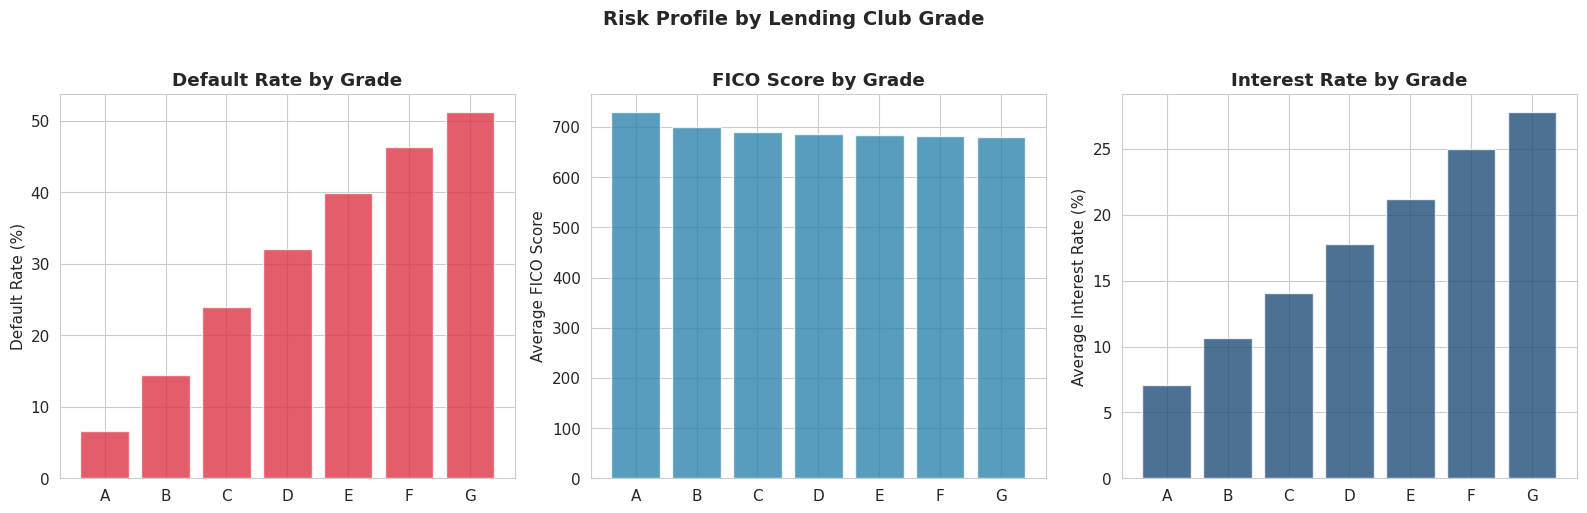

In [20]:
# Grade visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

grades = grade_analysis.index.tolist()
x = range(len(grades))

axes[0].bar(x, grade_analysis['default_rate'] * 100, color=COLORS['bad'], alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(grades)
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Grade', fontweight='bold')

axes[1].bar(x, grade_analysis['avg_fico'], color=COLORS['accent'], alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(grades)
axes[1].set_ylabel('Average FICO Score')
axes[1].set_title('FICO Score by Grade', fontweight='bold')

axes[2].bar(x, grade_analysis['avg_int_rate'], color=COLORS['primary'], alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(grades)
axes[2].set_ylabel('Average Interest Rate (%)')
axes[2].set_title('Interest Rate by Grade', fontweight='bold')

plt.suptitle('Risk Profile by Lending Club Grade', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/04_grade_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Missing Value Analysis

Features with missing values: 60 out of 90



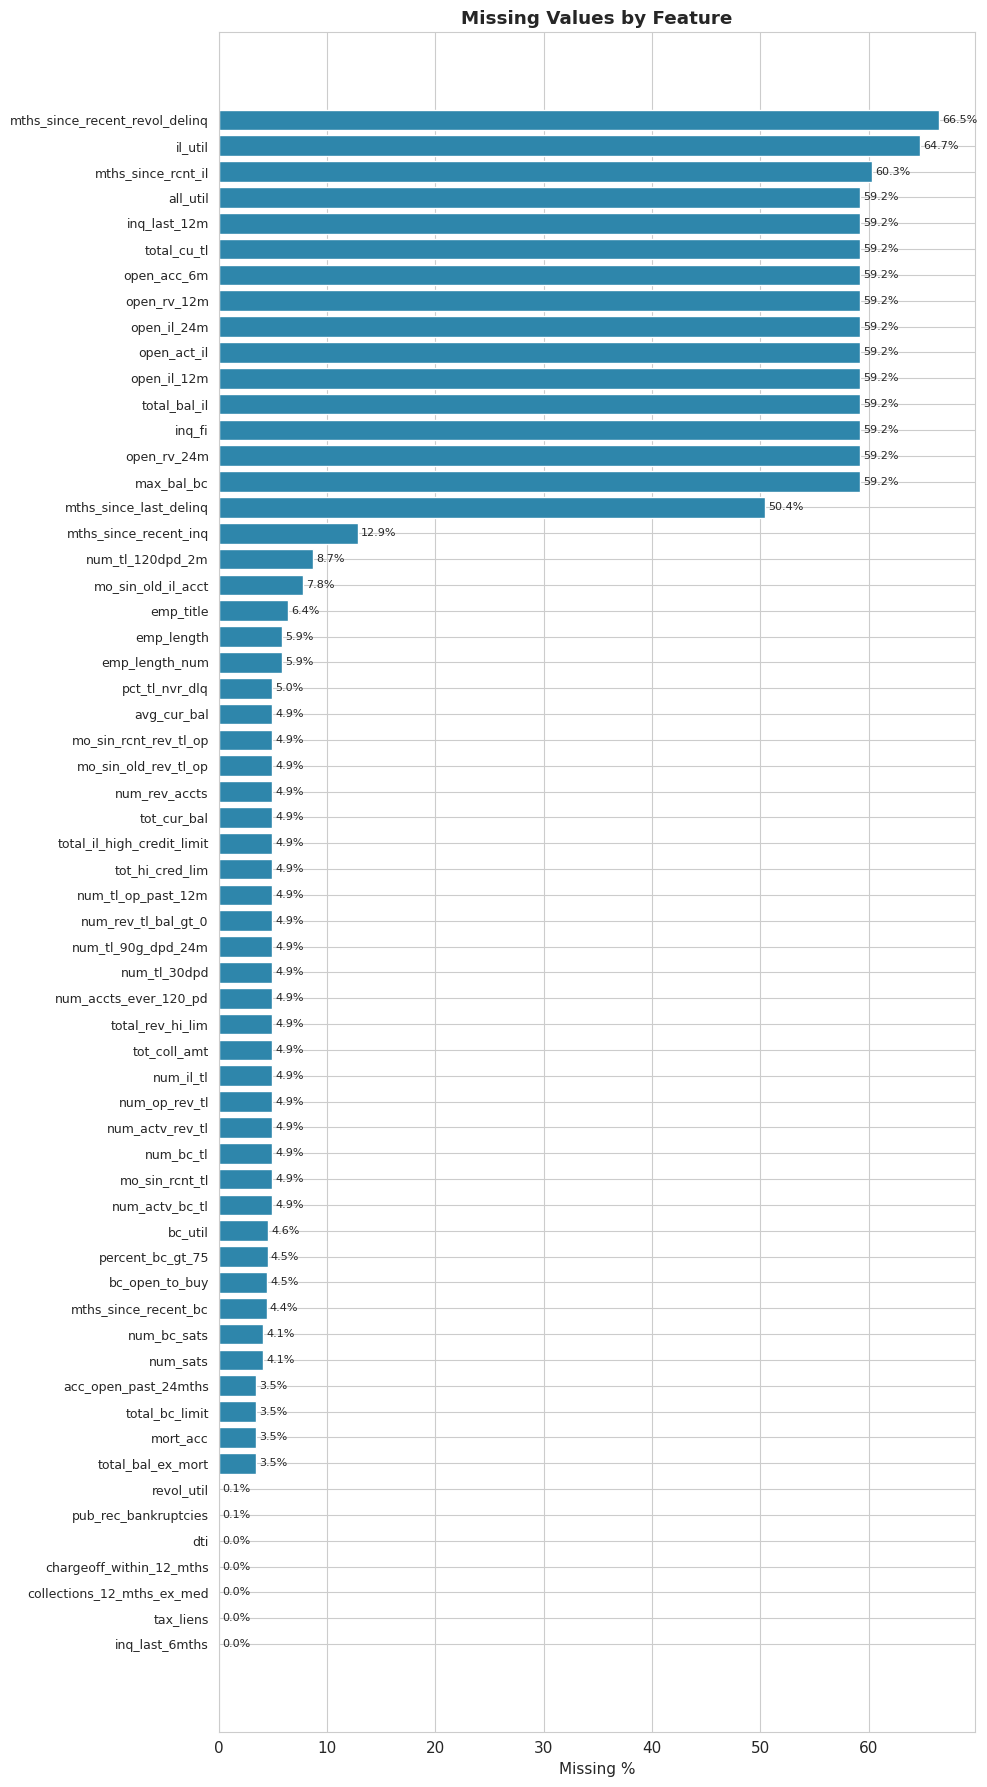

In [21]:
missing = df.isnull().mean()
missing_features = missing[missing > 0].sort_values(ascending=False)

print(f'Features with missing values: {len(missing_features)} out of {df.shape[1]}\n')

if len(missing_features) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_features) * 0.3)))
    ax.barh(range(len(missing_features)), missing_features.values * 100, color=COLORS['accent'])
    ax.set_yticks(range(len(missing_features)))
    ax.set_yticklabels(missing_features.index, fontsize=9)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Feature', fontweight='bold')
    ax.invert_yaxis()

    for i, val in enumerate(missing_features.values):
        ax.text(val * 100 + 0.3, i, f'{val*100:.1f}%', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('figures/05_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()

In [22]:
# Is missingness related to default? (MAR vs MCAR)
print('=== Missing Rate by Default Status ===')
print('(Large differences suggest Missing At Random - MAR)\n')

for col in missing_features.head(15).index:
    miss_def = df[df['default'] == 1][col].isnull().mean() * 100
    miss_non = df[df['default'] == 0][col].isnull().mean() * 100
    diff = abs(miss_def - miss_non)
    flag = ' !!!' if diff > 2 else ''
    print(f'  {col:35s} | Non-Def: {miss_non:5.1f}% | Def: {miss_def:5.1f}% | Diff: {diff:.1f}%{flag}')

=== Missing Rate by Default Status ===
(Large differences suggest Missing At Random - MAR)

  mths_since_recent_revol_delinq      | Non-Def:  66.9% | Def:  65.3% | Diff: 1.6%
  il_util                             | Non-Def:  66.6% | Def:  58.0% | Diff: 8.6% !!!
  mths_since_rcnt_il                  | Non-Def:  62.2% | Def:  53.3% | Diff: 8.9% !!!
  all_util                            | Non-Def:  61.2% | Def:  51.7% | Diff: 9.5% !!!
  inq_last_12m                        | Non-Def:  61.2% | Def:  51.7% | Diff: 9.5% !!!
  total_cu_tl                         | Non-Def:  61.2% | Def:  51.7% | Diff: 9.5% !!!
  open_acc_6m                         | Non-Def:  61.2% | Def:  51.7% | Diff: 9.5% !!!
  open_rv_12m                         | Non-Def:  61.2% | Def:  51.7% | Diff: 9.5% !!!
  open_il_24m                         | Non-Def:  61.2% | Def:  51.7% | Diff: 9.5% !!!
  open_act_il                         | Non-Def:  61.2% | Def:  51.7% | Diff: 9.5% !!!
  open_il_12m                         | No

## 10. Correlation Analysis

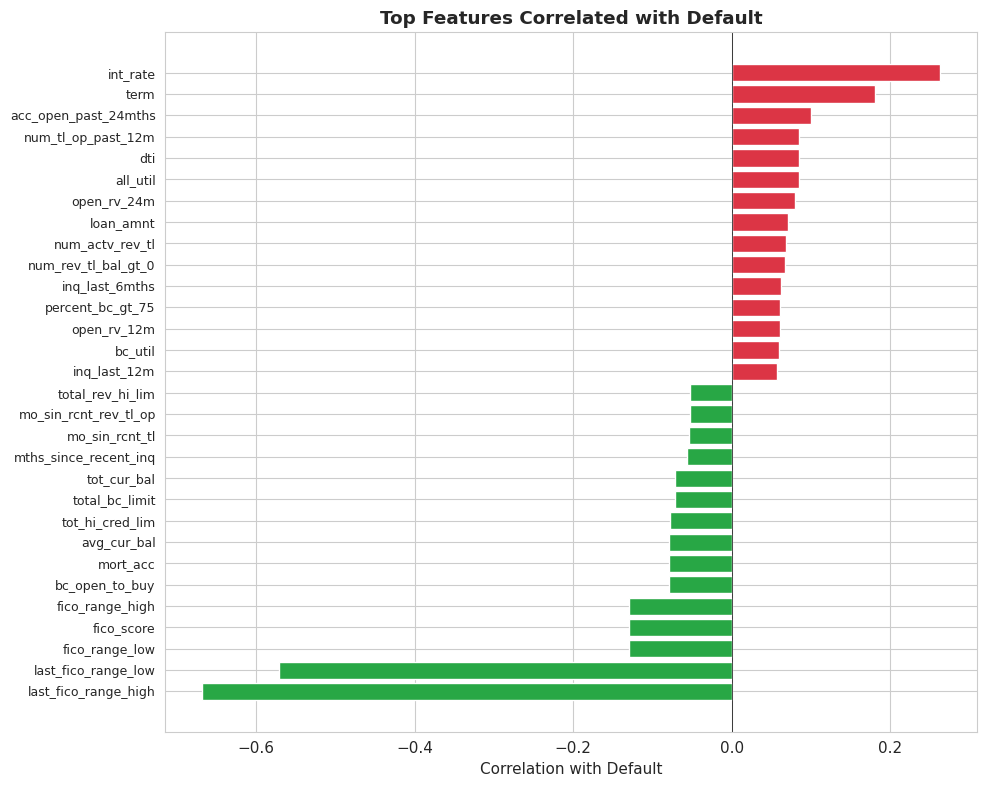

In [23]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'default']

target_corr = df[numeric_cols + ['default']].corr()['default'].drop('default').sort_values()
top_bottom = pd.concat([target_corr.head(15), target_corr.tail(15)])

fig, ax = plt.subplots(figsize=(10, 8))
colors = [COLORS['bad'] if v > 0 else COLORS['good'] for v in top_bottom.values]
ax.barh(range(len(top_bottom)), top_bottom.values, color=colors)
ax.set_yticks(range(len(top_bottom)))
ax.set_yticklabels(top_bottom.index, fontsize=9)
ax.set_xlabel('Correlation with Default')
ax.set_title('Top Features Correlated with Default', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('figures/06_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Multicollinearity: |r| > 0.8
corr_matrix = df[numeric_cols].corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_pairs:
    corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(f'=== Highly Correlated Feature Pairs (|r| > 0.8) ===')
    print(f'Total: {len(corr_df)} pairs\n')
    print(corr_df.to_string(index=False))
    print('\nNote: Consider dropping one from each pair or using VIF in feature engineering.')
else:
    print('No highly correlated pairs found (|r| > 0.8).')

=== Highly Correlated Feature Pairs (|r| > 0.8) ===
Total: 26 pairs

             Feature 1                      Feature 2  Correlation
        fico_range_low                fico_range_high        1.000
        fico_range_low                     fico_score        1.000
       fico_range_high                     fico_score        1.000
              open_acc                       num_sats        0.999
       num_actv_rev_tl            num_rev_tl_bal_gt_0        0.982
           tot_cur_bal                tot_hi_cred_lim        0.973
          total_bal_il     total_il_high_credit_limit        0.957
             loan_amnt                    installment        0.953
  mo_sin_old_rev_tl_op          credit_history_months        0.907
          total_bal_il              total_bal_ex_mort        0.901
     total_bal_ex_mort     total_il_high_credit_limit        0.873
mths_since_last_delinq mths_since_recent_revol_delinq        0.866
            revol_util                        bc_util       

## 11. Text Features Preview (for LLM Processing)

`emp_title` has thousands of messy variations — this is where LLM-assisted feature engineering adds real value.

In [25]:
if 'emp_title' in df.columns:
    print(f'emp_title: {df["emp_title"].nunique():,} unique values')
    print(f'Missing: {df["emp_title"].isnull().mean()*100:.1f}%')
    print(f'\nTop 20 most common:')
    print(df['emp_title'].value_counts().head(20))

    print('\n--- Why we need LLM: variations of similar jobs ---')
    for keyword in ['teach', 'nurs', 'manag', 'driver', 'engineer']:
        variants = df[df['emp_title'].str.contains(keyword, case=False, na=False)]['emp_title'].nunique()
        print(f'  Titles containing "{keyword}": {variants} unique variants')

emp_title: 381,808 unique values
Missing: 6.4%

Top 20 most common:
emp_title
Teacher               21604
Manager               19847
Owner                 10678
Registered Nurse       8938
RN                     8670
Supervisor             8464
Driver                 7777
Sales                  7623
Project Manager        6461
Office Manager         5617
General Manager        5302
Director               5092
owner                  4708
manager                4603
Engineer               4353
President              4271
teacher                4148
Vice President         3584
driver                 3576
Operations Manager     3521
Name: count, dtype: int64

--- Why we need LLM: variations of similar jobs ---
  Titles containing "teach": 2054 unique variants
  Titles containing "nurs": 3840 unique variants
  Titles containing "manag": 35285 unique variants
  Titles containing "driver": 3596 unique variants
  Titles containing "engineer": 8178 unique variants


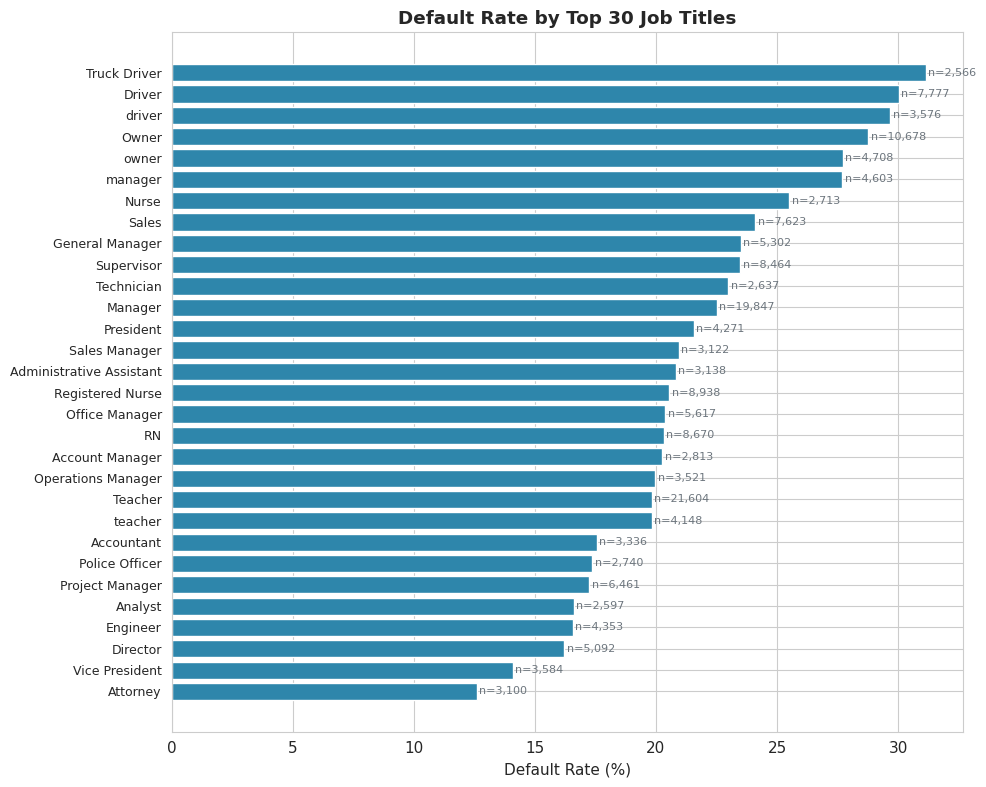

In [26]:
# Default rate by common job titles
if 'emp_title' in df.columns:
    top_titles = df['emp_title'].value_counts().head(30).index
    title_default = df[df['emp_title'].isin(top_titles)].groupby('emp_title')['default'].agg(['mean', 'count'])
    title_default.columns = ['default_rate', 'count']
    title_default = title_default.sort_values('default_rate', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(title_default)), title_default['default_rate'] * 100, color=COLORS['accent'])
    ax.set_yticks(range(len(title_default)))
    ax.set_yticklabels(title_default.index, fontsize=9)
    ax.set_xlabel('Default Rate (%)')
    ax.set_title('Default Rate by Top 30 Job Titles', fontweight='bold')

    for j, (rate, count) in enumerate(zip(title_default['default_rate'], title_default['count'])):
        ax.text(rate * 100 + 0.1, j, f'n={count:,}', va='center', fontsize=8, color=COLORS['neutral'])

    plt.tight_layout()
    plt.savefig('figures/07_job_title_default_rates.png', dpi=150, bbox_inches='tight')
    plt.show()

## 12. Geographic Analysis

Understanding US geographic variation gives us a basis for the cross-regional transfer story.

In [27]:
if 'addr_state' in df.columns:
    state_analysis = df.groupby('addr_state').agg(
        count=('default', 'count'),
        default_rate=('default', 'mean'),
        avg_income=('annual_inc', 'mean'),
        avg_dti=('dti', 'mean'),
    ).round(3)
    state_analysis = state_analysis[state_analysis['count'] >= 500]
    state_analysis = state_analysis.sort_values('default_rate', ascending=False)

    print('=== Top 10 States by Default Rate (min 500 loans) ===')
    print(state_analysis.head(10).to_string())
    print('\n=== Bottom 10 States by Default Rate ===')
    print(state_analysis.tail(10).to_string())

    print(f'\nDefault rate range: {state_analysis["default_rate"].min()*100:.1f}% - {state_analysis["default_rate"].max()*100:.1f}%')
    print('Even within the US, there\'s significant geographic variation.')
    print('This supports our hypothesis that cross-regional differences matter.')

=== Top 10 States by Default Rate (min 500 loans) ===
             count  default_rate  avg_income  avg_dti
addr_state                                           
MS            6795         0.283   69465.264   20.641
NE            3677         0.270   64415.922   20.196
AR           10223         0.254   66623.972   20.235
AL           16914         0.250   68903.010   20.161
OK           12499         0.248   70738.227   19.923
LA           15752         0.244   74720.382   19.373
NY          111897         0.235   79395.991   16.569
FL           97450         0.230   71398.398   18.521
NV           20552         0.230   71902.611   18.551
MD           31841         0.228   84321.695   17.781

=== Bottom 10 States by Default Rate ===
            count  default_rate  avg_income  avg_dti
addr_state                                          
MT           3862         0.177   62487.896   20.176
SC          16230         0.175   72590.270   19.383
WA          29555         0.168   75909.889 

## 13. Save Processed Data

In [28]:
# Save locally + to Drive
df.to_parquet('data/processed/lending_club_cleaned.parquet', index=False)
df.to_parquet(f'{DRIVE_DIR}/data/processed/lending_club_cleaned.parquet', index=False)

print(f'Saved cleaned data:')
print(f'  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'  Default rate: {df["default"].mean()*100:.2f}%')
print(f'  Drive path: {DRIVE_DIR}/data/processed/lending_club_cleaned.parquet')

Saved cleaned data:
  Shape: 1,366,817 rows x 90 columns
  Default rate: 21.22%
  Drive path: /content/drive/MyDrive/is5126/data/processed/lending_club_cleaned.parquet


In [29]:
# Save emp_title separately for LLM processing
if 'emp_title' in df.columns:
    emp_data = df[['emp_title', 'default']].dropna(subset=['emp_title'])
    emp_data.to_csv(f'{DRIVE_DIR}/data/processed/emp_titles_for_llm.csv', index=False)
    print(f'Saved {len(emp_data):,} emp_titles for LLM processing')

Saved 1,279,007 emp_titles for LLM processing


## 14. EDA Summary

**Fill in after running. These findings guide feature engineering in notebook 02.**

| Item | Finding |
|------|--------|
| Dataset size | 1,366,817 loans after filtering |
| Default rate | 21.22% |
| Strongest positive predictors (higher = more default) | int_rate, dti, delinq_2yrs |
| Strongest negative predictors (higher = less default) | fico_score, annual_inc, open_acc |
| Multicollinearity issues | 26 pairs with \|r\| > 0.8 |
| Missing value strategy | Drop columns >70% missing (22 dropped); median/mode imputation for remaining 60 features with partial nulls |
| emp_title unique values | 381,808 (needs LLM) |
| Grade A vs G default rate | 6.6% vs 51.2% |
| Geographic variation | 14.2% to 28.3% across states |

**Cross-regional transfer implications (for Phase 3):**
- Features most affected by cultural differences: `emp_title` (job title conventions differ), `home_ownership` (high ownership rates in SG), `purpose` (loan purpose norms vary), `addr_state` (US-specific geography)
- Features likely universal across markets: `int_rate`, `dti`, `fico_score` (or local equivalent), `loan_amnt`, `delinq_2yrs`, `inq_last_6mths`
- SG data availability challenges: No direct FICO equivalent (use CBS credit score); joint-applicant fields unavailable; employment title taxonomy differs significantly from US

---

**Next: Notebook 02 → Feature Engineering (standard + LLM-assisted)**